In [11]:
!pip install pandas numpy matplotlib seaborn scikit-learn gradio openpyxl

In [12]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import gradio as gr

In [13]:
df = pd.read_csv("resume_data_for_ranking.csv")

In [22]:
print("Dataset Shape:", df.shape)
print(df.columns.tolist())
display(df.head())

Dataset Shape: (9544, 37)
['address', 'career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'educational_results', 'result_types', 'major_field_of_studies', 'professional_company_names', 'company_urls', 'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'locations', 'responsibilities', 'extra_curricular_activity_types', 'extra_curricular_organization_names', 'extra_curricular_organization_links', 'role_positions', 'languages', 'proficiency_levels', 'certification_providers', 'certification_skills', 'online_links', 'issue_dates', 'expiry_dates', 'job_position_name', 'educationaL_requirements', 'experiencere_requirement', 'age_requirement', 'responsibilities.1', 'skills_required', 'matched_score', 'resume_text', 'job_text']


,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,expiry_dates,job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score,resume_text,job_text
0,,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,,Technical Support\nTroubleshooting\nCollaborat...,,0.850000,Big data analytics working and database wareho...,Senior Software Engineer B.Sc in Computer Scie...
1,,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),,Machine Learning Leadership\nCross-Functional ...,,0.750000,Fresher looking to join as a data analyst and ...,Machine Learning (ML) Engineer M.Sc in Compute...
2,,,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667,"['Software Development', 'Machine Learning', ...","Executive/ Senior Executive- Trade Marketing, ..."
3,,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name...",...,,Business Development Executive,Bachelor/Honors,1 to 3 years,Age 22 to 30 years,Apparel Sourcing\nQuality Garment Sourcing\nRe...,Fast typing skill\nIELTSInternet browsing & on...,0.760000,To obtain a position in a fast-paced business ...,Business Development Executive Bachelor/Honors...
4,,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,"['February 15, 2021']",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.650000,Professional accountant with an outstanding wo...,Senior iOS Engineer Bachelor of Science (BSc) ...


In [21]:
df["resume_text"] = (
    df["career_objective"].fillna("").astype(str)
    + " "
    + df["skills"].fillna("").astype(str)
    + " "
    + df["responsibilities"].fillna("").astype(str)
    + " "
    + df["degree_names"].fillna("").astype(str)
    + " "
    + df["major_field_of_studies"].fillna("").astype(str)
)

df["job_text"] = (
    df["job_position_name"].fillna("").astype(str)
    + " "
    + df["educationaL_requirements"].fillna("").astype(str)
    + " "
    + df["experiencere_requirement"].fillna("").astype(str)
    + " "
    + df["responsibilities.1"].fillna("").astype(str)
    + " "
    + df["skills_required"].fillna("").astype(str)
)

In [23]:
df = df[
    (df["resume_text"].str.strip() != "") &
    (df["job_text"].str.strip() != "")
].copy()

print("Dataset after cleaning:", df.shape)

Dataset after cleaning: (9544, 37)


In [24]:
df = df[
    (df["resume_text"].str.strip() != "") &
    (df["job_text"].str.strip() != "")
].copy()

print("Dataset after cleaning:", df.shape)

Dataset after cleaning: (9544, 37)


In [25]:
print(
    "Duplicates:",
    df.duplicated().sum()
)

df = df.drop_duplicates()

print(
    "After removing duplicates:",
    df.shape
)

Duplicates: 0
After removing duplicates: (9544, 37)


In [26]:
def clean_text(text):

    text = text.lower()

    text = re.sub(
        r"[^a-zA-Z0-9\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [27]:
df["resume_clean"] = df["resume_text"].apply(
    clean_text
)

df["job_clean"] = df["job_text"].apply(
    clean_text
)

In [28]:
print("Original:")
print(df["resume_text"].iloc[0][:500])

print("\nCleaned:")
print(df["resume_clean"].iloc[0][:500])

Original:
Big data analytics working and database warehouse manager with robust experience in handling all kinds of data. I have also used multiple cloud infrastructure services and am well acquainted with them. Currently in search of role that offers more of development. ['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapreduce', 'Spark', 'Java', 'Machine Learning', 'Cloud', 'Hdfs', 'YARN', 'Core Java', 'Data Science', 'C++', 'Data Structures', 'DBMS', 'RDBMS', 'Informatica', 'Talend', 'Amazon Redshift', 'Micr

Cleaned:
big data analytics working and database warehouse manager with robust experience in handling all kinds of data i have also used multiple cloud infrastructure services and am well acquainted with them currently in search of role that offers more of development big data hadoop hive python mapreduce spark java machine learning cloud hdfs yarn core java data science c data structures dbms rdbms informatica talend amazon redshift microsoft azure technical support troubleshooting 

In [29]:
df["resume_length"] = (
    df["resume_clean"]
    .str.split()
    .str.len()
)

df["job_length"] = (
    df["job_clean"]
    .str.split()
    .str.len()
)

In [30]:
df["resume_length"] = (
    df["resume_clean"]
    .str.split()
    .str.len()
)

df["job_length"] = (
    df["job_clean"]
    .str.split()
    .str.len()
)

In [31]:
print(
    df[
        ["resume_length", "job_length"]
    ].describe()
)

       resume_length   job_length
count    9544.000000  9544.000000
mean       87.122381    46.996857
std        46.208104    13.324106
min        15.000000    27.000000
25%        58.000000    41.000000
50%        78.000000    45.000000
75%       103.000000    53.000000
max       442.000000    82.000000


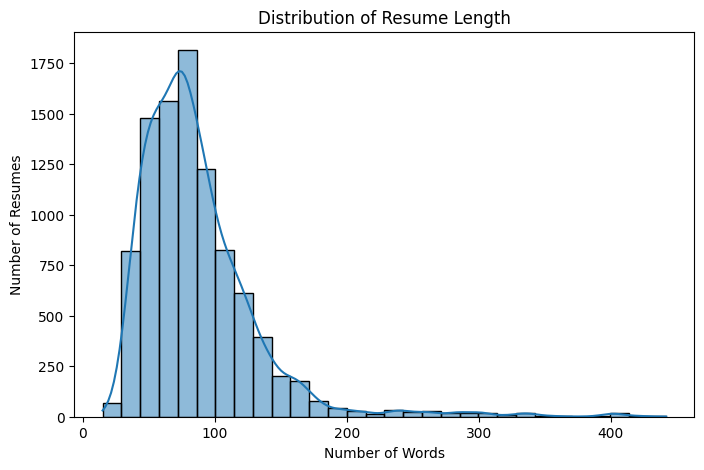

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["resume_length"],
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Resume Length"
)

plt.xlabel("Number of Words")

plt.ylabel("Number of Resumes")

plt.show()

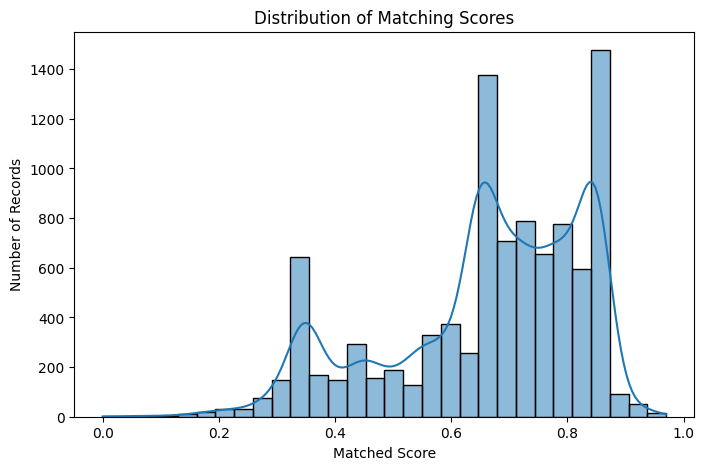

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["matched_score"],
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Matching Scores"
)

plt.xlabel("Matched Score")

plt.ylabel("Number of Records")

plt.show()

In [34]:
Q1 = df["resume_length"].quantile(0.25)

Q3 = df["resume_length"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = df[
    (df["resume_length"] < lower) |
    (df["resume_length"] > upper)
]

print(
    "Number of resume text outliers:",
    len(outliers)
)

Number of resume text outliers: 367


In [35]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

In [36]:
all_text = pd.concat(
    [
        df["resume_clean"],
        df["job_clean"]
    ]
)

tfidf.fit(all_text)

TfidfVectorizer(max_features=5000, stop_words='english')

In [37]:
resume_vectors = tfidf.transform(
    df["resume_clean"]
)

job_vectors = tfidf.transform(
    df["job_clean"]
)

In [38]:
similarity_scores = []

for i in range(len(df)):

    score = cosine_similarity(
        resume_vectors[i],
        job_vectors[i]
    )[0][0]

    similarity_scores.append(
        score * 100
    )

In [39]:
df["tfidf_score"] = similarity_scores

In [40]:
display(
    df[
        [
            "job_position_name",
            "matched_score",
            "tfidf_score"
        ]
    ].head(10)
)

,job_position_name,matched_score,tfidf_score
0,Senior Software Engineer,0.850000,22.932846
1,Machine Learning (ML) Engineer,0.750000,70.793222
2,"Executive/ Senior Executive- Trade Marketing, ...",0.416667,56.947658
3,Business Development Executive,0.760000,24.058643
4,Senior iOS Engineer,0.650000,30.786453
5,AI Engineer,0.850000,20.659398
6,Senior iOS Engineer,0.650000,53.570371
7,Senior iOS Engineer,0.650000,27.218439
8,Mechanical Engineer,0.550000,18.133054
9,Business Development Executive,0.383333,35.518157


In [41]:
print(
    df["matched_score"].describe()
)

count    9544.000000
mean        0.660831
std         0.167040
min         0.000000
25%         0.583333
50%         0.683333
75%         0.793333
max         0.970000
Name: matched_score, dtype: float64


In [42]:
df["label"] = (
    df["matched_score"] >= 0.5
).astype(int)

In [43]:
df["label"] = (
    df["matched_score"] >= 50
).astype(int)

In [44]:
print(df["matched_score"].head())

0    0.850000
1    0.750000
2    0.416667
3    0.760000
4    0.650000
Name: matched_score, dtype: float64


In [49]:
# Create two classes using the median score

threshold = df["matched_score"].median()

df["label"] = (
    df["matched_score"] >= threshold
).astype(int)

print("Threshold:", threshold)

print("\nClass Distribution:")
print(df["label"].value_counts())

Threshold: 0.683333333

Class Distribution:
label
1    5139
0    4405
Name: count, dtype: int64


In [50]:
df["combined_text"] = (
    df["resume_clean"] +
    " " +
    df["job_clean"]
)

In [51]:
tfidf_model = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X = tfidf_model.fit_transform(
    df["combined_text"]
)

y = df["label"]

print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (9544, 3217)


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = LogisticRegression(
    max_iter=500
)

model.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully!")


Logistic Regression trained successfully!


In [53]:
y_pred = model.predict(
    X_test
)

In [54]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("================================")
print("LOGISTIC REGRESSION RESULTS")
print("================================")

print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1 Score :", round(f1, 3))

LOGISTIC REGRESSION RESULTS
Accuracy : 0.746
Precision: 0.754
Recall   : 0.783
F1 Score : 0.768


In [55]:
tfidf_match = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

resume_vectors = tfidf_match.fit_transform(
    df["resume_clean"]
)

job_vectors = tfidf_match.transform(
    df["job_clean"]
)

scores = []

for i in range(len(df)):

    similarity = cosine_similarity(
        resume_vectors[i],
        job_vectors[i]
    )[0][0]

    scores.append(
        similarity * 100
    )

df["tfidf_match_score"] = scores

In [56]:
display(
    df[
        [
            "job_position_name",
            "matched_score",
            "tfidf_match_score"
        ]
    ].head(10)
)


,job_position_name,matched_score,tfidf_match_score
0,Senior Software Engineer,0.850000,20.395128
1,Machine Learning (ML) Engineer,0.750000,71.641328
2,"Executive/ Senior Executive- Trade Marketing, ...",0.416667,59.340563
3,Business Development Executive,0.760000,26.270969
4,Senior iOS Engineer,0.650000,32.268500
5,AI Engineer,0.850000,21.728161
6,Senior iOS Engineer,0.650000,54.625835
7,Senior iOS Engineer,0.650000,28.584091
8,Mechanical Engineer,0.550000,18.949867
9,Business Development Executive,0.383333,37.235231


In [57]:
df["score_difference"] = (
    df["matched_score"] * 100
    - df["tfidf_match_score"]
)

display(
    df[
        [
            "job_position_name",
            "matched_score",
            "tfidf_match_score",
            "score_difference"
        ]
    ].head(10)
)

,job_position_name,matched_score,tfidf_match_score,score_difference
0,Senior Software Engineer,0.850000,20.395128,64.604872
1,Machine Learning (ML) Engineer,0.750000,71.641328,3.358672
2,"Executive/ Senior Executive- Trade Marketing, ...",0.416667,59.340563,-17.673896
3,Business Development Executive,0.760000,26.270969,49.729031
4,Senior iOS Engineer,0.650000,32.268500,32.731500
5,AI Engineer,0.850000,21.728161,63.271839
6,Senior iOS Engineer,0.650000,54.625835,10.374165
7,Senior iOS Engineer,0.650000,28.584091,36.415909
8,Mechanical Engineer,0.550000,18.949867,36.050133
9,Business Development Executive,0.383333,37.235231,1.098102


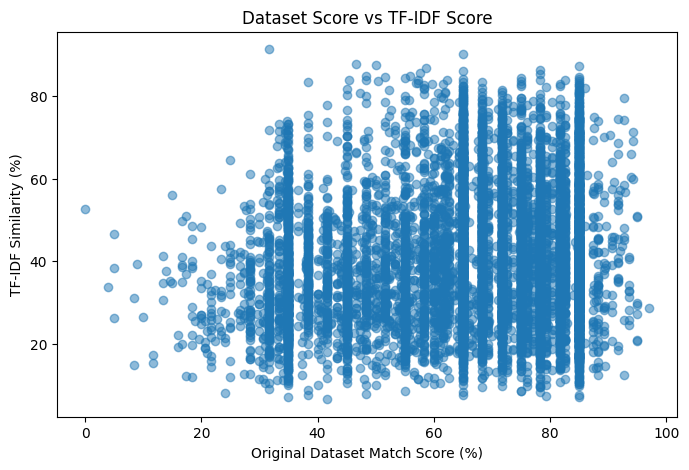

In [58]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["matched_score"] * 100,
    df["tfidf_match_score"],
    alpha=0.5
)

plt.xlabel("Original Dataset Match Score (%)")
plt.ylabel("TF-IDF Similarity (%)")
plt.title("Dataset Score vs TF-IDF Score")

plt.show()

In [59]:
def find_skill_gap(resume, job):

    resume = resume.lower()
    job = job.lower()

    common_skills = [
        "python",
        "java",
        "sql",
        "machine learning",
        "deep learning",
        "pandas",
        "numpy",
        "power bi",
        "excel",
        "tableau",
        "tensorflow",
        "nlp",
        "statistics",
        "data analysis",
        "scikit-learn",
        "matplotlib",
        "seaborn"
    ]

    resume_skills = []

    job_skills = []

    for skill in common_skills:

        if skill in resume:
            resume_skills.append(skill)

        if skill in job:
            job_skills.append(skill)

    matching = list(
        set(resume_skills) &
        set(job_skills)
    )

    missing = list(
        set(job_skills) -
        set(resume_skills)
    )

    return matching, missing

In [60]:
def job_matcher(resume, job):

    resume = clean_text(resume)

    job = clean_text(job)

    # TF-IDF

    vectors = tfidf.transform(
        [resume, job]
    )

    score = cosine_similarity(
        vectors[0:1],
        vectors[1:2]
    )[0][0] * 100

    # Skills

    matching, missing = find_skill_gap(
        resume,
        job
    )

    # Recommendation

    if score >= 75:

        recommendation = "🟢 Strong Match"

    elif score >= 50:

        recommendation = "🟡 Moderate Match"

    else:

        recommendation = "🔴 Low Match"

    return (
        f"Match Score: {score:.2f}%\n\n"
        f"Recommendation: {recommendation}\n\n"
        f"Matching Skills: "
        f"{', '.join(matching) if matching else 'None'}\n\n"
        f"Missing Skills: "
        f"{', '.join(missing) if missing else 'None'}"
    )

In [61]:
demo = gr.Interface(

    fn=job_matcher,

    inputs=[
        gr.Textbox(
            label="📄 Resume",
            lines=10,
            placeholder="Paste your resume here..."
        ),

        gr.Textbox(
            label="💼 Job Description",
            lines=10,
            placeholder="Paste the job description here..."
        )
    ],

    outputs=gr.Textbox(
        label="🎯 Matching Result",
        lines=8
    ),

    title="Smart Job Matching and Skill Gap Analysis",

    description=(
        "Enter a resume and job description "
        "to calculate their NLP similarity "
        "and identify skill gaps."
    )
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7a4e59d2135b1cce3f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
